# Modelos Predictivos Preliminares — M5 Forecasting

**Objetivo (E2):** Obtener resultados preliminares comparando tres enfoques de modelado
sobre series representativas del dataset M5, como base para la Sección 9 del TFM.

**Modelos implementados:**
1. Naïve Estacional (s=7) — *baseline* de referencia
2. SARIMA — modelo estadístico clásico (via `pmdarima.auto_arima`)
3. LightGBM — modelo de gradiente boosting con características de lag

**Series representativas seleccionadas (tienda CA_1, horizonte=28 días):**
- Una serie por categoría (FOODS, HOUSEHOLD, HOBBIES) con baja intermitencia
- Serie agregada FOODS CA_1 (suma de todos los productos FOODS en CA_1)

**Split:** entrenamiento d\_1–d\_1885 | validación d\_1886–d\_1913 (últimos 28 días)


---
## 1. Configuración e imports


In [1]:
%pip install lightgbm --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pmdarima import auto_arima

warnings.filterwarnings('ignore')
sns.set_palette('muted')

# Paleta y marcadores consistentes en todas las figuras
MODEL_COLORS = {
    'Naïve Estacional': '#4878d0',
    'Naïve':            '#4878d0',
    'SARIMA':           '#ee854a',
    'LightGBM':         '#6acc65',
}
MODEL_LS  = {'Naïve': '--',  'SARIMA': '-.',  'LightGBM': ':'}
MODEL_MRK = {'Naïve': 'o',   'SARIMA': 's',   'LightGBM': '^'}

# Estilo global para figuras de calidad académica
plt.rcParams.update({
    'figure.figsize'    : (13, 5),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.linestyle'    : '--',
    'grid.alpha'        : 0.35,
    'axes.axisbelow'    : True,
    'font.size'         : 11,
    'axes.labelsize'    : 11,
    'axes.titlesize'    : 12,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 9,
    'legend.framealpha' : 0.75,
})

FIGURES_DIR = Path('imagenes/media')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path('data/m5')

H = 28  # horizonte de predicción en días

print(f'Horizonte de predicción : {H} días')
print(f'Figuras en              : {FIGURES_DIR.resolve()}')


Horizonte de predicción : 28 días
Figuras en              : C:\Users\chavju01\Documents\Maestria\semestre3\trabajo_final\imagenes\media


---
## 2. Carga de datos y split tren/validación


In [3]:
print('Cargando datos...')
sales    = pd.read_csv(DATA_DIR / 'sales_train_validation.csv')
calendar = pd.read_csv(DATA_DIR / 'calendar.csv', parse_dates=['date'])

id_cols  = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
day_cols = [c for c in sales.columns if c.startswith('d_')]
n_days   = len(day_cols)           # 1913
TRAIN_DAYS = n_days - H            # 1885

print(f'Series         : {len(sales):,}')
print(f'Días totales   : {n_days:,}   (d_1 – d_{n_days})')
print(f'Entrenamiento  : d_1  – d_{TRAIN_DAYS}  ({TRAIN_DAYS} días)')
print(f'Validación     : d_{TRAIN_DAYS+1} – d_{n_days}  ({H} días)')


Cargando datos...
Series         : 30,490
Días totales   : 1,913   (d_1 – d_1913)
Entrenamiento  : d_1  – d_1885  (1885 días)
Validación     : d_1886 – d_1913  (28 días)


In [4]:
# Selección: serie por categoría con menor % de ceros en CA_1
pct_ceros = (sales[day_cols] == 0).mean(axis=1)

rep_series = {}
for cat in ['FOODS', 'HOUSEHOLD', 'HOBBIES']:
    mask = (sales['cat_id'] == cat) & (sales['store_id'] == 'CA_1')
    best = sales[mask].loc[(pct_ceros[mask]).idxmin()]
    rep_series[cat] = best['id']
    print(f'{cat:<10}: {best["id"]}  (% ceros: {pct_ceros[best.name]*100:.1f}%)')

# Serie agregada FOODS CA_1
rep_series['FOODS_CA1_AGG'] = 'FOODS_CA1_AGG'
print(f'{"AGGREGATE":<10}: FOODS CA_1 (suma de todas las series FOODS en CA_1)')
print(f'\nTotal series seleccionadas: {len(rep_series)}')


FOODS     : FOODS_3_080_CA_1_validation  (% ceros: 0.3%)
HOUSEHOLD : HOUSEHOLD_1_373_CA_1_validation  (% ceros: 5.8%)
HOBBIES   : HOBBIES_1_254_CA_1_validation  (% ceros: 12.3%)
AGGREGATE : FOODS CA_1 (suma de todas las series FOODS en CA_1)

Total series seleccionadas: 4


In [5]:
def get_series(series_id: str) -> np.ndarray:
    """Extrae una serie temporal como array numpy float64."""
    if series_id == 'FOODS_CA1_AGG':
        y = sales[(sales['cat_id'] == 'FOODS') & (sales['store_id'] == 'CA_1')][day_cols].sum().values
    else:
        y = sales[sales['id'] == series_id][day_cols].values.flatten()
    return y.astype(float)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, label: str = '') -> dict:
    """RMSE, MAE y MAPE (solo posiciones con y_true > 0)."""
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mask = y_true > 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.sum() > 0 else np.nan
    if label:
        print(f'    {label:<16}  RMSE={rmse:7.3f}  MAE={mae:7.3f}  MAPE={mape:5.1f}%')
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


# Vista rápida de las series seleccionadas
print('Vista previa de series representativas:')
print(f'  {"Serie":<16}  {"Sum train":>12}  {"Sum val":>10}  {"Mean val":>9}  {"% ceros val":>12}')
print('  ' + '─' * 65)
for name, sid in rep_series.items():
    y = get_series(sid)
    y_tr = y[:TRAIN_DAYS]; y_v = y[TRAIN_DAYS:]
    pct_v = (y_v == 0).mean() * 100
    print(f'  {name:<16}  {y_tr.sum():>12,.0f}  {y_v.sum():>10,.0f}  {y_v.mean():>9.2f}  {pct_v:>11.1f}%')


Vista previa de series representativas:
  Serie                Sum train     Sum val   Mean val   % ceros val
  ─────────────────────────────────────────────────────────────────
  FOODS                   38,626         519      18.54          0.0%
  HOUSEHOLD                9,730         117       4.18          0.0%
  HOBBIES                 14,824         217       7.75         10.7%
  FOODS_CA1_AGG        5,296,160      84,668    3023.86          0.0%


---
## 3. Modelo 1: Naïve Estacional (baseline, s=7)

La predicción para el horizonte $h$ es el valor observado exactamente 7 días antes:

$$\hat{y}_{t+h} = y_{t+h-7}$$

Equivale a repetir el patrón de la última semana completa de entrenamiento.


In [6]:
# Naïve Estacional s=7
print('Modelo 1: Naïve Estacional (s=7) \n')

results_naive = {}
naive_preds   = {}

for name, sid in rep_series.items():
    y       = get_series(sid)
    y_train = y[:TRAIN_DAYS]
    y_val   = y[TRAIN_DAYS:]

    # Repetir las últimas 7 obs de entrenamiento, tantas veces como sea necesario
    y_pred = np.tile(y_train[-7:], (H // 7) + 1)[:H]

    metrics = compute_metrics(y_val, y_pred, label=name)
    results_naive[name] = metrics
    naive_preds[name]   = y_pred

print('\nNaïve completado.')


Modelo 1: Naïve Estacional (s=7) 

    FOODS             RMSE= 12.087  MAE=  9.107  MAPE= 64.4%
    HOUSEHOLD         RMSE=  2.758  MAE=  2.107  MAPE= 62.8%
    HOBBIES           RMSE=  7.702  MAE=  6.036  MAPE=106.8%
    FOODS_CA1_AGG     RMSE=420.116  MAE=343.857  MAPE= 10.9%

Naïve completado.


---
## 4. Modelo 2: SARIMA (auto_arima, m=7)

Se usa `pmdarima.auto_arima` con búsqueda *stepwise* para seleccionar el orden
$(p, d, q)(P, D, Q)_7$ que minimiza el AIC. El test ADF del EDA justifica $d=1$
y la estacionalidad semanal clara justifica $D=1$, $m=7$.


In [7]:
# SARIMA con pmdarima
print('Modelo 2: SARIMA (auto_arima, m=7) \n')
print('Restricciones: max_p=2, max_q=2, max_P=1, max_Q=1, d=1, D=1, stepwise=True\n')

results_sarima = {}
sarima_preds   = {}
sarima_orders  = {}

for name, sid in rep_series.items():
    y       = get_series(sid)
    y_train = y[:TRAIN_DAYS]
    y_val   = y[TRAIN_DAYS:]

    print(f'  Ajustando {name}...', end=' ', flush=True)
    model = auto_arima(
        y_train,
        start_p=1, start_q=1,
        max_p=2,   max_q=2,
        m=7,       seasonal=True,
        start_P=0, start_Q=0,
        max_P=1,   max_Q=1,
        d=1,       D=1,
        information_criterion='aic',
        stepwise=True,
        error_action='ignore',
        suppress_warnings=True,
    )
    order = f'SARIMA{model.order}x{model.seasonal_order}'
    print(f'{order}')
    sarima_orders[name] = order

    y_pred = model.predict(n_periods=H)
    y_pred = np.clip(y_pred, 0, None)  # no negativos

    metrics = compute_metrics(y_val, y_pred, label=name)
    results_sarima[name] = metrics
    sarima_preds[name]   = y_pred

print('\nSARIMA completado.')


Modelo 2: SARIMA (auto_arima, m=7) 

Restricciones: max_p=2, max_q=2, max_P=1, max_Q=1, d=1, D=1, stepwise=True

  Ajustando FOODS... SARIMA(2, 1, 0)x(1, 1, 0, 7)
    FOODS             RMSE= 12.970  MAE= 10.485  MAPE= 52.6%
  Ajustando HOUSEHOLD... SARIMA(2, 1, 0)x(1, 1, 0, 7)
    HOUSEHOLD         RMSE=  3.228  MAE=  2.727  MAPE=104.7%
  Ajustando HOBBIES... SARIMA(2, 1, 0)x(1, 1, 0, 7)
    HOBBIES           RMSE=  6.310  MAE=  4.785  MAPE= 69.9%
  Ajustando FOODS_CA1_AGG... SARIMA(2, 1, 0)x(1, 1, 0, 7)
    FOODS_CA1_AGG     RMSE=363.402  MAE=300.284  MAPE=  9.8%

SARIMA completado.


---
## 5. Modelo 3: LightGBM (características de lag)

Enfoque tabular con *lags* desplazados ≥ 28 días para evitar fuga de información
(*data leakage*) en predicción directa multihorizonte. Se entrena un modelo
por serie usando las características:

| Feature | Descripción |
|---|---|
| `lag_28 … lag_56` | Ventas de hace 28, 35, 42, 49, 56 días |
| `roll_mean_28` | Media de 28 días con offset de 28 días |
| `roll_mean_7` | Media de 7 días con offset de 28 días |
| `wday`, `month` | Día de la semana (1–7) y mes |
| `snap_CA` | Indicador SNAP activo en California |
| `has_event` | Si hay evento especial en el calendario |


In [8]:
FEATURE_COLS = [
    'lag_28', 'lag_35', 'lag_42', 'lag_49', 'lag_56',
    'roll_mean_28', 'roll_mean_7',
    'wday', 'month', 'snap_CA', 'has_event',
]

def make_lgb_dataset(y_arr: np.ndarray, calendar_df: pd.DataFrame) -> pd.DataFrame:
    """
    Construye dataset tabular con features de lag (offset >= 28 días).
    Empieza en t=56 para que lag_56 esté siempre disponible.
    """
    cal = calendar_df[['d', 'wday', 'month', 'snap_CA', 'event_type_1']].copy()
    cal['day_num'] = cal['d'].str.replace('d_', '', regex=False).astype(int)
    cal = cal.set_index('day_num')

    n = len(y_arr)
    records = []
    for t in range(56, n):
        dn = t + 1  # 1-indexed day number
        rec = {
            'day_num'      : dn,
            'target'       : y_arr[t],
            'lag_28'       : y_arr[t - 28],
            'lag_35'       : y_arr[t - 35],
            'lag_42'       : y_arr[t - 42],
            'lag_49'       : y_arr[t - 49],
            'lag_56'       : y_arr[t - 56],
            'roll_mean_28' : float(np.mean(y_arr[t - 56 : t - 28])),  # 28 obs, lag 28
            'roll_mean_7'  : float(np.mean(y_arr[t - 35 : t - 28])),  # 7 obs, lag 28
        }
        if dn in cal.index:
            cr = cal.loc[dn]
            rec['wday']      = int(cr['wday'])
            rec['month']     = int(cr['month'])
            rec['snap_CA']   = int(cr['snap_CA'])
            rec['has_event'] = 0 if pd.isna(cr['event_type_1']) else 1
        else:
            rec['wday'] = rec['month'] = rec['snap_CA'] = rec['has_event'] = 0
        records.append(rec)

    return pd.DataFrame(records)

print('Función make_lgb_dataset definida.')
print(f'Features: {FEATURE_COLS}')


Función make_lgb_dataset definida.
Features: ['lag_28', 'lag_35', 'lag_42', 'lag_49', 'lag_56', 'roll_mean_28', 'roll_mean_7', 'wday', 'month', 'snap_CA', 'has_event']


In [9]:
# Entrenamiento LightGBM
print('Modelo 3: LightGBM (local, 200 rondas) \n')

results_lgb = {}
lgb_models  = {}
lgb_preds   = {}

lgb_params = {
    'objective'        : 'regression_l2',
    'metric'           : 'rmse',
    'num_leaves'       : 31,
    'learning_rate'    : 0.05,
    'min_child_samples': 10,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 1,
    'verbose'          : -1,
}

for name, sid in rep_series.items():
    y   = get_series(sid)
    df  = make_lgb_dataset(y, calendar)

    df_train = df[df['day_num'] <= TRAIN_DAYS].dropna(subset=FEATURE_COLS)
    df_val   = df[(df['day_num'] > TRAIN_DAYS) & (df['day_num'] <= n_days)].dropna(subset=FEATURE_COLS)

    X_tr, y_tr = df_train[FEATURE_COLS], df_train['target']
    X_v,  y_v  = df_val[FEATURE_COLS],   df_val['target']

    print(f'  {name:<16}  train={len(X_tr):,} | val={len(X_v):,}', end='  ')

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    model  = lgb.train(lgb_params, dtrain, num_boost_round=200,
                       callbacks=[lgb.log_evaluation(0)])

    y_pred = np.clip(model.predict(X_v), 0, None)

    metrics = compute_metrics(y_v.values, y_pred, label='')
    print(f'RMSE={metrics["RMSE"]:7.3f}  MAE={metrics["MAE"]:7.3f}  MAPE={metrics["MAPE"]:5.1f}%')

    results_lgb[name] = metrics
    lgb_models[name]  = model
    lgb_preds[name]   = y_pred

print('\nLightGBM completado.')


Modelo 3: LightGBM (local, 200 rondas) 

  FOODS             train=1,829 | val=28  RMSE=  6.647  MAE=  5.243  MAPE= 32.9%
  HOUSEHOLD         train=1,829 | val=28  RMSE=  2.754  MAE=  2.219  MAPE= 53.1%
  HOBBIES           train=1,829 | val=28  RMSE=  5.373  MAE=  4.497  MAPE=129.6%
  FOODS_CA1_AGG     train=1,829 | val=28  RMSE=192.929  MAE=160.529  MAPE=  5.5%

LightGBM completado.


---
## 6. Comparación de resultados


In [10]:
# Tabla comparativa
rows = []
for name in rep_series:
    for model_label, res_dict in [
        ('Naïve Estacional', results_naive),
        ('SARIMA',           results_sarima),
        ('LightGBM',         results_lgb),
    ]:
        if name in res_dict:
            m = res_dict[name]
            rows.append({
                'Serie'    : name,
                'Modelo'   : model_label,
                'RMSE'     : round(m['RMSE'], 3),
                'MAE'      : round(m['MAE'],  3),
                'MAPE (%)'  : round(m['MAPE'], 1),
            })

df_results = pd.DataFrame(rows)

print('Tabla comparativa — validación 28 días \n')
print(df_results.to_string(index=False))

# Mejor modelo por serie (menor RMSE)
print('\nMejor modelo por RMSE')
best = df_results.loc[df_results.groupby('Serie')['RMSE'].idxmin()][['Serie','Modelo','RMSE','MAE']]
print(best.to_string(index=False))


Tabla comparativa — validación 28 días 

        Serie           Modelo    RMSE     MAE  MAPE (%)
        FOODS Naïve Estacional  12.087   9.107      64.4
        FOODS           SARIMA  12.970  10.485      52.6
        FOODS         LightGBM   6.647   5.243      32.9
    HOUSEHOLD Naïve Estacional   2.758   2.107      62.8
    HOUSEHOLD           SARIMA   3.228   2.727     104.7
    HOUSEHOLD         LightGBM   2.754   2.219      53.1
      HOBBIES Naïve Estacional   7.702   6.036     106.8
      HOBBIES           SARIMA   6.310   4.785      69.9
      HOBBIES         LightGBM   5.373   4.497     129.6
FOODS_CA1_AGG Naïve Estacional 420.116 343.857      10.9
FOODS_CA1_AGG           SARIMA 363.402 300.284       9.8
FOODS_CA1_AGG         LightGBM 192.929 160.529       5.5

Mejor modelo por RMSE
        Serie   Modelo    RMSE     MAE
        FOODS LightGBM   6.647   5.243
FOODS_CA1_AGG LightGBM 192.929 160.529
      HOBBIES LightGBM   5.373   4.497
    HOUSEHOLD LightGBM   2.754   2.219


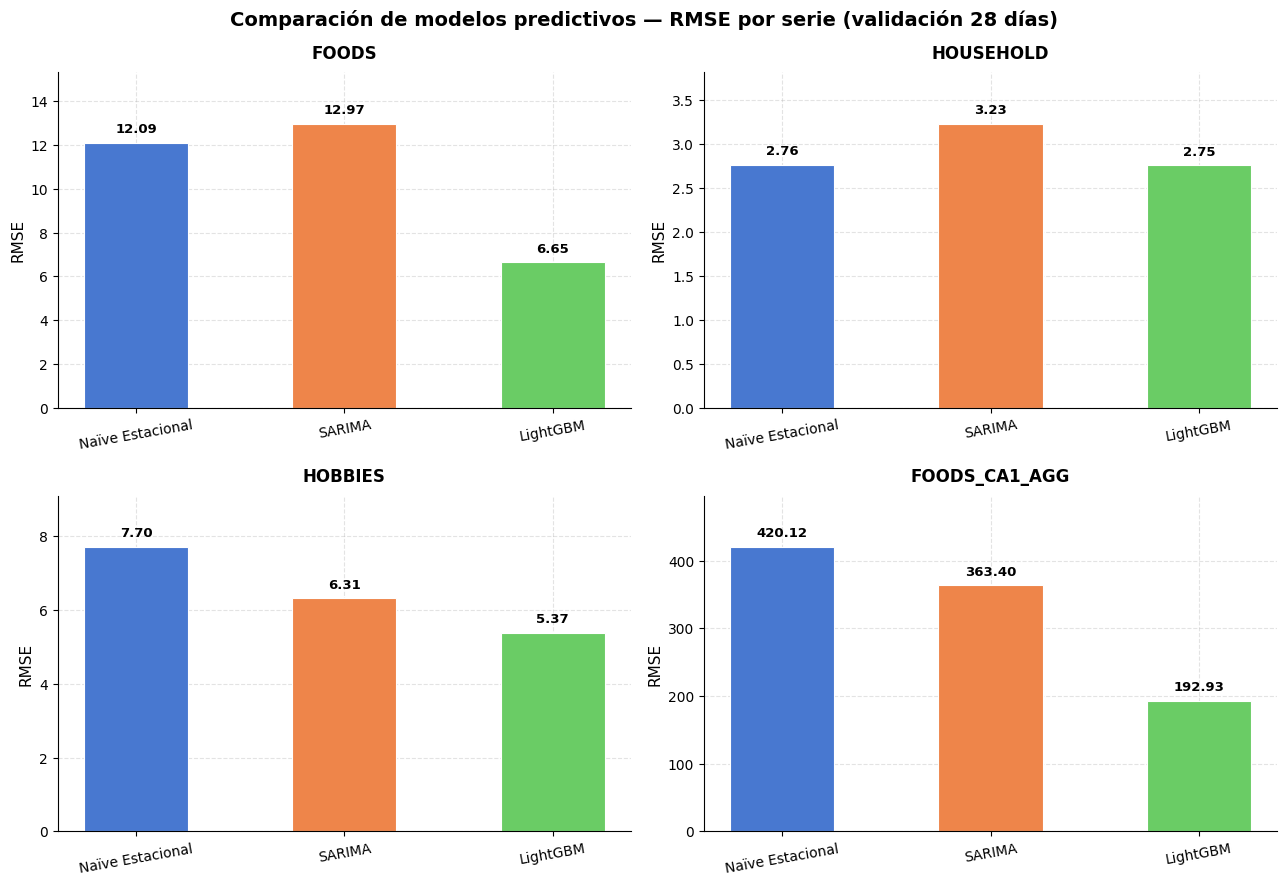

In [11]:
# RMSE por modelo — 2×2 (un subplot por serie, escala independiente)
series_order = list(rep_series.keys())
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, name in enumerate(series_order):
    ax   = axes[i]
    sub  = df_results[df_results['Serie'] == name].copy()
    cols = [MODEL_COLORS[m] for m in sub['Modelo']]
    bars = ax.bar(sub['Modelo'], sub['RMSE'], color=cols,
                  width=0.5, edgecolor='white', linewidth=0.8)

    # Anotación del valor encima de cada barra
    offset = sub['RMSE'].max() * 0.025
    for bar, val in zip(bars, sub['RMSE']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold',
        )

    ax.set_title(name, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('RMSE', fontsize=11)
    ax.tick_params(axis='x', rotation=10, labelsize=10)
    ax.set_ylim(bottom=0, top=sub['RMSE'].max() * 1.18)

plt.suptitle(
    'Comparación de modelos predictivos — RMSE por serie (validación 28 días)',
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_comparacion_modelos.png', dpi=220, bbox_inches='tight')
plt.show()


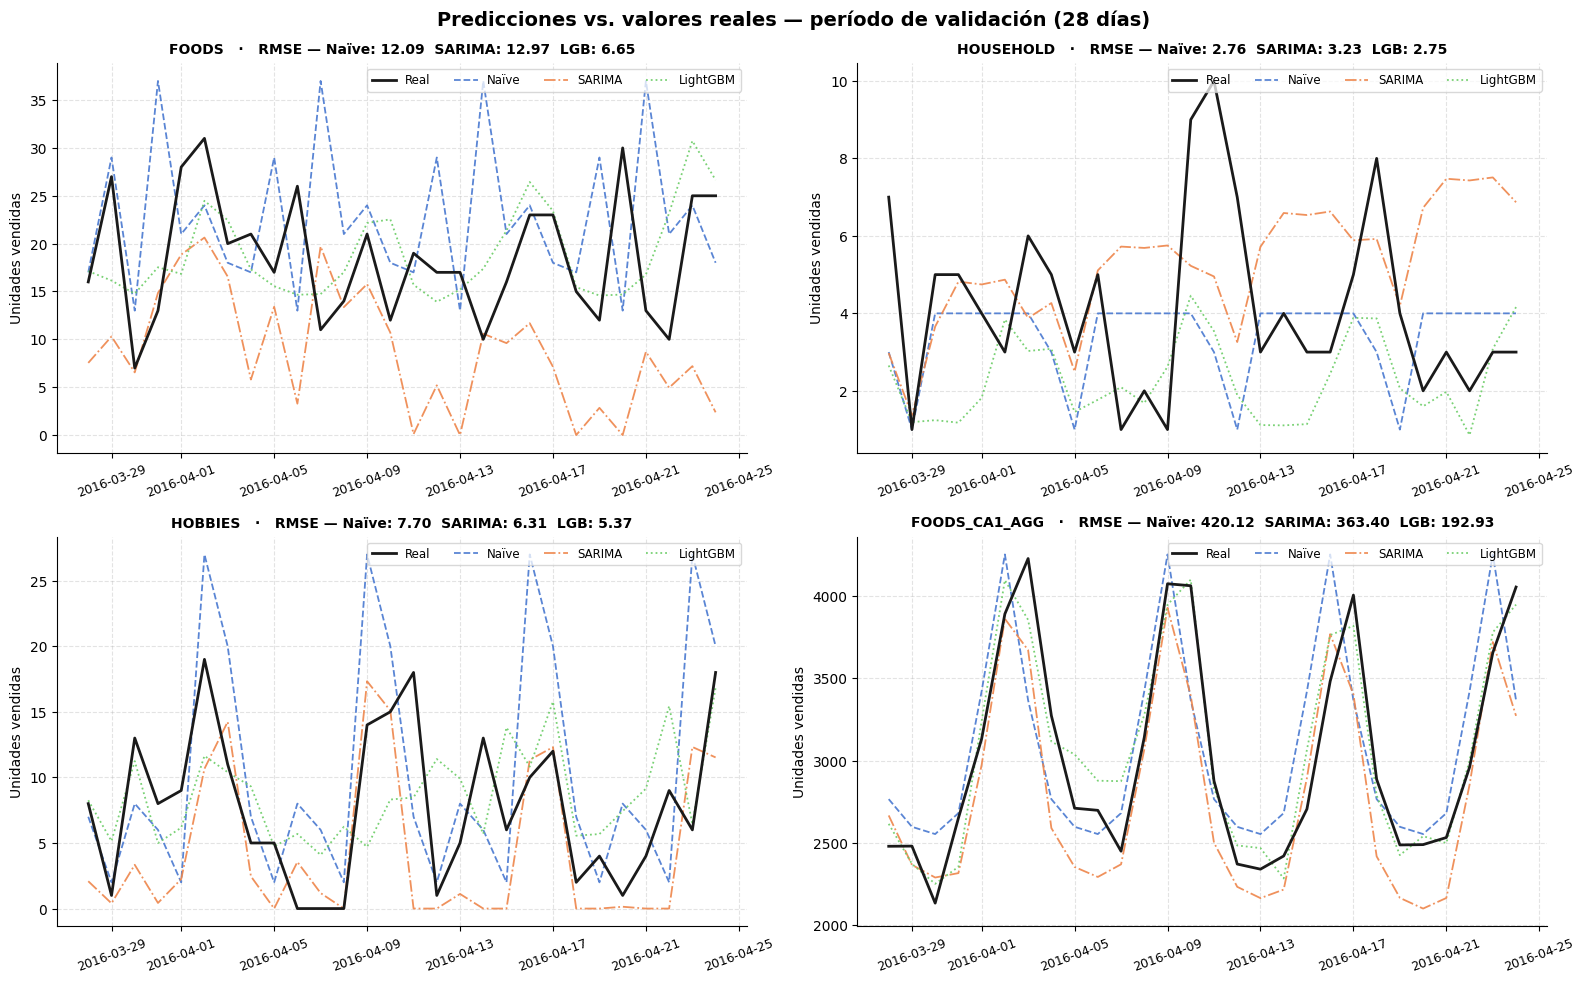

In [12]:
# Predicciones vs real — 2×2 (un subplot por serie)
val_dates   = calendar[calendar['d'].isin(
    [f'd_{i}' for i in range(TRAIN_DAYS + 1, n_days + 1)]
)]['date'].values
series_list = list(rep_series.items())

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
axes = axes.flatten()

for i, (name, sid) in enumerate(series_list):
    ax    = axes[i]
    y_val = get_series(sid)[TRAIN_DAYS:]

    ax.plot(val_dates, y_val,
            color='#1a1a1a', linewidth=2.0, label='Real', zorder=5)
    ax.plot(val_dates, naive_preds[name],
            color=MODEL_COLORS['Naïve'],  linewidth=1.3, linestyle='--',
            label='Naïve', alpha=0.9)
    ax.plot(val_dates, sarima_preds[name],
            color=MODEL_COLORS['SARIMA'], linewidth=1.3, linestyle='-.',
            label='SARIMA', alpha=0.9)
    ax.plot(val_dates, lgb_preds[name],
            color=MODEL_COLORS['LightGBM'], linewidth=1.3, linestyle=':',
            label='LightGBM', alpha=0.9)

    ax.set_title(
        f'{name}   ·   RMSE — Naïve: {results_naive[name]["RMSE"]:.2f}  '
        f'SARIMA: {results_sarima[name]["RMSE"]:.2f}  '
        f'LGB: {results_lgb[name]["RMSE"]:.2f}',
        fontsize=10, fontweight='bold', pad=7,
    )
    ax.set_ylabel('Unidades vendidas', fontsize=10)
    ax.legend(loc='upper right', ncol=4, fontsize=8.5)
    ax.tick_params(axis='x', rotation=20, labelsize=9)

plt.suptitle(
    'Predicciones vs. valores reales — período de validación (28 días)',
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_predicciones_vs_real.png', dpi=220, bbox_inches='tight')
plt.show()


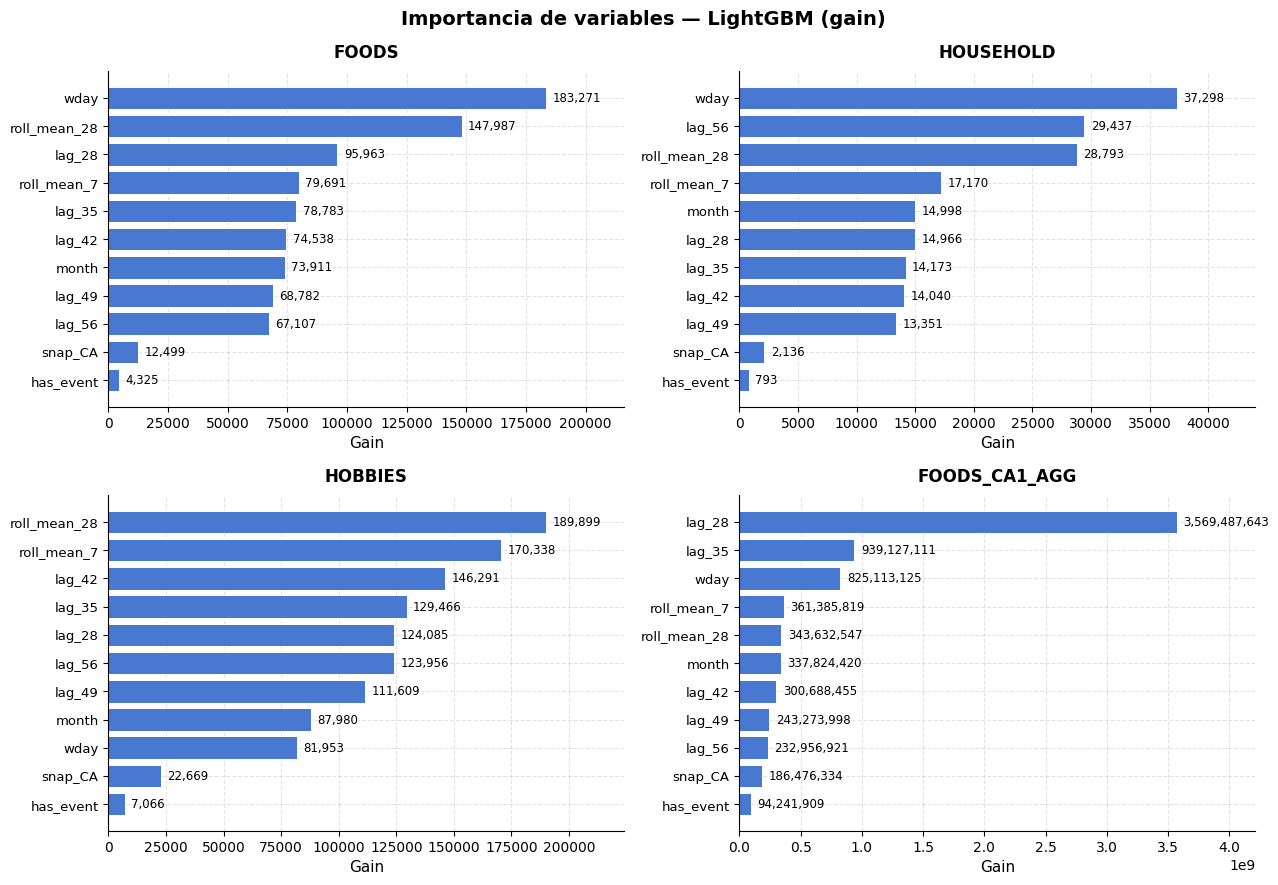

In [13]:
# Importancia de variables LightGBM — 2×2 con anotaciones
models_list = list(lgb_models.items())
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(models_list):
    ax  = axes[i]
    imp = pd.Series(
        model.feature_importance(importance_type='gain'),
        index=FEATURE_COLS,
    ).sort_values()

    bars = ax.barh(imp.index, imp.values,
                   color='#4878d0', edgecolor='white', linewidth=0.7)

    # Anotación del valor al final de cada barra
    x_offset = imp.values.max() * 0.015
    for bar, val in zip(bars, imp.values):
        ax.text(
            val + x_offset,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}',
            va='center', fontsize=8.5,
        )

    ax.set_title(name, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Gain', fontsize=11)
    ax.tick_params(axis='y', labelsize=9.5)
    ax.set_xlim(right=imp.values.max() * 1.18)

plt.suptitle(
    'Importancia de variables — LightGBM (gain)',
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_feature_importance.png', dpi=220, bbox_inches='tight')
plt.show()


---
## 7. Pruebas de sensibilidad

Se analiza cómo varía el RMSE de cada modelo en función del **horizonte de predicción** evaluado: 7, 14, 21 y 28 días. Este análisis responde a la pregunta: ¿la calidad de las predicciones se degrada al alejarse del inicio del período de validación?

Se evalúan los tres modelos sobre los primeros $h$ días del período de validación ($h \in \{7, 14, 21, 28\}$), usando las predicciones ya generadas. Dado que los modelos producen predicciones fijas (no recursivas), esta prueba evalúa la **estabilidad del error acumulado** según el horizonte elegido.


RMSE por horizonte de predicción

Horizonte                    7        14       21       28
Serie         Modelo                                      
FOODS         LightGBM    7.302    6.829    6.062    6.647
              Naïve      10.135   11.395   11.468   12.087
              SARIMA      8.920   10.079   11.189   12.970
FOODS_CA1_AGG LightGBM  215.004  224.166  217.888  192.929
              Naïve     418.396  393.011  428.159  420.116
              SARIMA    272.176  353.995  342.572  363.402
HOBBIES       LightGBM    3.622    4.853    5.699    5.373
              Naïve       5.669    6.188    7.188    7.702
              SARIMA      6.674    5.130    6.602    6.310
HOUSEHOLD     LightGBM    2.975    2.713    2.990    2.754
              Naïve       1.813    2.375    2.828    2.758
              SARIMA      1.953    2.676    2.930    3.228


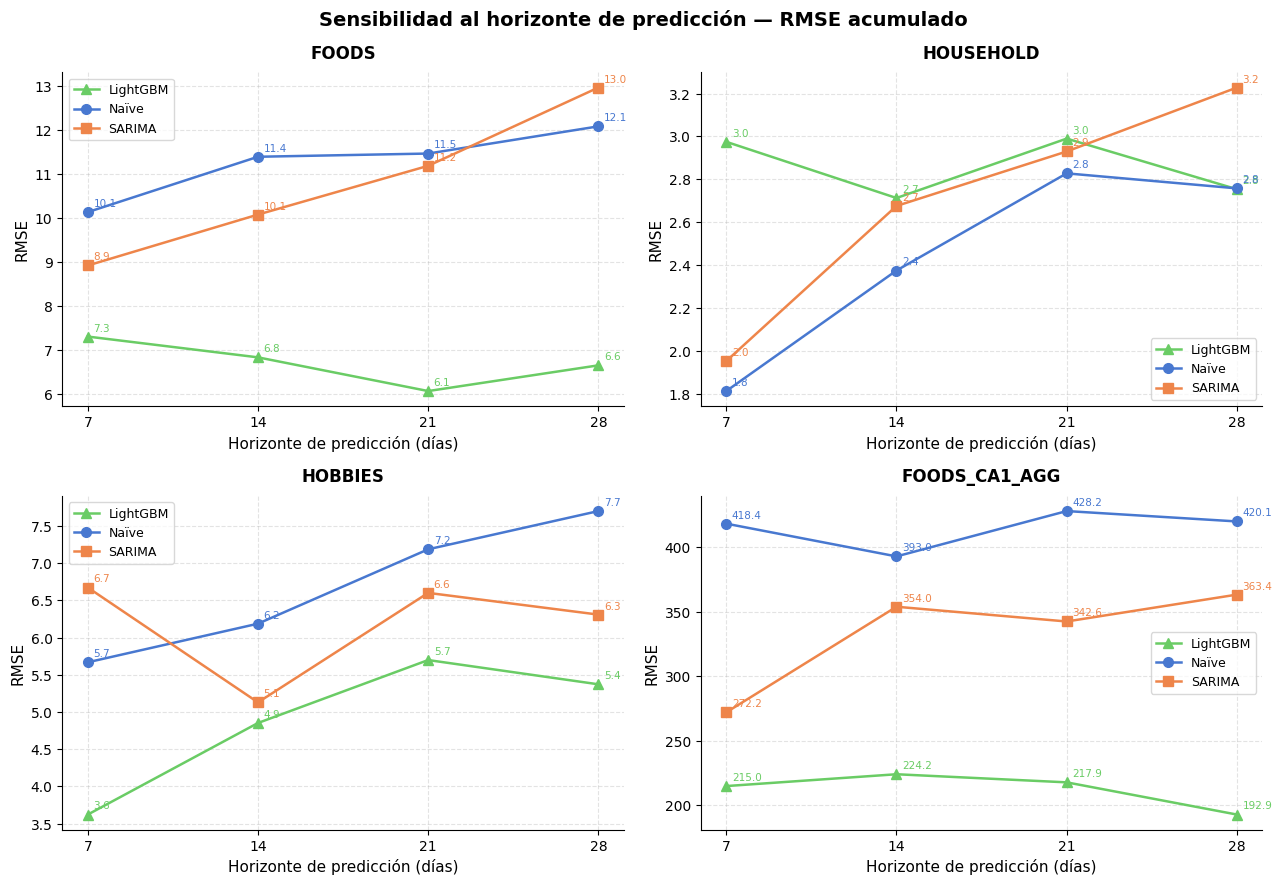

Figura guardada: fig_sensibilidad_horizonte.png


In [14]:
# Sensibilidad al horizonte de predicción
horizons = [7, 14, 21, 28]
horizon_records = []

for name in rep_series:
    y_val = get_series(rep_series[name])[TRAIN_DAYS:]
    for h in horizons:
        for model_label, preds_dict in [
            ('Naïve',    naive_preds),
            ('SARIMA',   sarima_preds),
            ('LightGBM', lgb_preds),
        ]:
            rmse_h = float(np.sqrt(mean_squared_error(y_val[:h], preds_dict[name][:h])))
            horizon_records.append({
                'Serie': name, 'Modelo': model_label,
                'Horizonte': h, 'RMSE': round(rmse_h, 3),
            })

df_horizon = pd.DataFrame(horizon_records)

# Tabla
print('RMSE por horizonte de predicción\n')
tbl = df_horizon.pivot_table(
    index=['Serie', 'Modelo'], columns='Horizonte', values='RMSE'
).round(3)
print(tbl.to_string())

# Gráfico 2×2
series_names = list(rep_series.keys())
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, name in enumerate(series_names):
    ax  = axes[i]
    sub = df_horizon[df_horizon['Serie'] == name]

    for mod, grp in sub.groupby('Modelo'):
        ax.plot(
            grp['Horizonte'], grp['RMSE'],
            marker=MODEL_MRK[mod], label=mod,
            color=MODEL_COLORS[mod], linewidth=1.8, markersize=7,
        )
        # Anotación en cada punto
        for _, row in grp.iterrows():
            ax.annotate(
                f'{row["RMSE"]:.1f}',
                xy=(row['Horizonte'], row['RMSE']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=7.5, color=MODEL_COLORS[mod],
            )

    ax.set_title(name, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Horizonte de predicción (días)', fontsize=11)
    ax.set_ylabel('RMSE', fontsize=11)
    ax.set_xticks(horizons)
    ax.legend(fontsize=9)

plt.suptitle(
    'Sensibilidad al horizonte de predicción — RMSE acumulado',
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_sensibilidad_horizonte.png', dpi=220, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_sensibilidad_horizonte.png')


---
## 8. Síntesis de resultados para el TFM


In [16]:
# Síntesis de hallazgos para la Sección 9 del TFM

print('SÍNTESIS DE RESULTADOS PRELIMINARES — E2')

print(f'Dataset       : M5 Forecasting (Walmart)')
print(f'Horizonte     : {H} días (d_{TRAIN_DAYS+1} – d_{n_days})')
print(f'Series eval.  : {len(rep_series)} (una por categoría + agregado CA_1)')
print()

# Tabla RMSE consolidada
print(f'{"Serie":<16}  {"Naïve":>8}  {"SARIMA":>8}  {"LightGBM":>10}  Mejor')
print('─' * 60)
for name in rep_series:
    r_n = results_naive[name]['RMSE']
    r_s = results_sarima[name]['RMSE']
    r_l = results_lgb[name]['RMSE']
    best_lbl = ['Naïve','SARIMA','LightGBM'][np.argmin([r_n, r_s, r_l])]
    mejora_vs_naive = (1 - min(r_s, r_l) / r_n) * 100
    print(f'{name:<16}  {r_n:>8.3f}  {r_s:>8.3f}  {r_l:>10.3f}  {best_lbl:<10}  '
          f'({mejora_vs_naive:+.1f}% vs naïve)')

print()
print('ÓRDENES SARIMA SELECCIONADOS POR auto_arima:')
for name, order in sarima_orders.items():
    print(f'  {name:<16}: {order}')

print()
print('FIGURAS GENERADAS PARA EL TFM:')
for fig_path in sorted(FIGURES_DIR.glob('fig_*.png')):
    print(f'  {fig_path.name}')
print()


SÍNTESIS DE RESULTADOS PRELIMINARES — E2
Dataset       : M5 Forecasting (Walmart)
Horizonte     : 28 días (d_1886 – d_1913)
Series eval.  : 4 (una por categoría + agregado CA_1)

Serie                Naïve    SARIMA    LightGBM  Mejor
────────────────────────────────────────────────────────────
FOODS               12.087    12.970       6.647  LightGBM    (+45.0% vs naïve)
HOUSEHOLD            2.758     3.228       2.754  LightGBM    (+0.1% vs naïve)
HOBBIES              7.702     6.310       5.373  LightGBM    (+30.2% vs naïve)
FOODS_CA1_AGG      420.116   363.402     192.929  LightGBM    (+54.1% vs naïve)

ÓRDENES SARIMA SELECCIONADOS POR auto_arima:
  FOODS           : SARIMA(2, 1, 0)x(1, 1, 0, 7)
  HOUSEHOLD       : SARIMA(2, 1, 0)x(1, 1, 0, 7)
  HOBBIES         : SARIMA(2, 1, 0)x(1, 1, 0, 7)
  FOODS_CA1_AGG   : SARIMA(2, 1, 0)x(1, 1, 0, 7)

FIGURAS GENERADAS PARA EL TFM:
  fig_acf_pacf.png
  fig_comparacion_modelos.png
  fig_dashboard.png
  fig_descomposicion_stl.png
  fig_dias_po